# Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from collections import Counter
import nltk
from nltk.corpus import stopwords

df = pd.read_csv(r"../data/raw/raw_dataset.csv")

print(f"Dataset loaded successfully with {len(df)} rows.")
df.head(5)

Dataset loaded successfully with 1910 rows.


,topic,platform,title,text,date,engagement,url
0,machine learning deployment,Reddit,google programmers deploy machine learning alg...,google programmers deploy machine learning alg...,2012-06-26 08:36:30,2260,https://reddit.com/r/science/comments/vlyjj/go...
1,machine learning deployment,Reddit,how i started learning machine learning,"hello, everyone. as promised, ill write a long...",2024-10-16 16:56:39,999,https://reddit.com/r/learnmachinelearning/comm...
2,machine learning deployment,Reddit,hiring remote machine learning developer oppor...,got a year or more of machine learning experie...,2026-02-25 16:11:16,13,https://reddit.com/r/MachineLearningJobs/comme...
3,machine learning deployment,Reddit,"handson machine learning with scikitlearn, ker...","handson machine learning with scikitlearn, ker...",2025-06-29 06:32:24,286,https://reddit.com/r/learnmachinelearning/comm...
4,machine learning deployment,Reddit,senior developers are expected to be able to d...,not meant to be a venting post but... ive been...,2023-11-18 03:52:00,298,https://reddit.com/r/ExperiencedDevs/comments/...


# Feature Engineering

In [2]:
import uuid
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('vader_lexicon', quiet=True)
sia = SentimentIntensityAnalyzer()

# Add Unique ID (Primary Key for Power BI)
df.insert(0, "post_id", [str(uuid.uuid4())[:8] for _ in range(len(df))])

# calculate text length for each post
df["word_count"] = df["text"].apply(lambda x: len(str(x).split()))
df["avg_word_length"] = df["text"].apply(lambda x: np.mean([len(w) for w in str(x).split()]) if len(str(x).split()) > 0 else 0)

# Add Sentiment Score (-1 to 1)
df["sentiment_score"] = df["text"].apply(lambda x: sia.polarity_scores(str(x))["compound"])

# Categorizes Sentiment 
df["sentiment_category"] = pd.cut(df["sentiment_score"],
                                 bins=[-1,-0.05, 0.05,1],
                                 labels=["Negative","Neutral", "Positive"])

# Add Engagement Tiers
df["engagement_tier"] = pd.qcut(df["engagement"].rank(method="first"),
                               q=3,
                               labels=["Low","Medium","High"])

df.head()

,post_id,topic,platform,title,text,date,engagement,url,word_count,avg_word_length,sentiment_score,sentiment_category,engagement_tier
0,ea050ef5,machine learning deployment,Reddit,google programmers deploy machine learning alg...,google programmers deploy machine learning alg...,2012-06-26 08:36:30,2260,https://reddit.com/r/science/comments/vlyjj/go...,16,6.375000,0.0000,Neutral,High
1,f7443239,machine learning deployment,Reddit,how i started learning machine learning,"hello, everyone. as promised, ill write a long...",2024-10-16 16:56:39,999,https://reddit.com/r/learnmachinelearning/comm...,1244,4.815113,0.9977,Positive,High
2,8c673ca0,machine learning deployment,Reddit,hiring remote machine learning developer oppor...,got a year or more of machine learning experie...,2026-02-25 16:11:16,13,https://reddit.com/r/MachineLearningJobs/comme...,60,5.933333,0.7236,Positive,High
3,87182bc8,machine learning deployment,Reddit,"handson machine learning with scikitlearn, ker...","handson machine learning with scikitlearn, ker...",2025-06-29 06:32:24,286,https://reddit.com/r/learnmachinelearning/comm...,208,5.254808,0.9724,Positive,High
4,3ced6174,machine learning deployment,Reddit,senior developers are expected to be able to d...,not meant to be a venting post but... ive been...,2023-11-18 03:52:00,298,https://reddit.com/r/ExperiencedDevs/comments/...,174,4.827586,0.5859,Positive,High


# Descriptive Text Behavior Analysis

### Platform & Topic Analysis

C:\Users\User\AppData\Local\Temp\ipykernel_20132\2640540108.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\User\AppData\Local\Temp\ipykernel_20132\2640540108.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


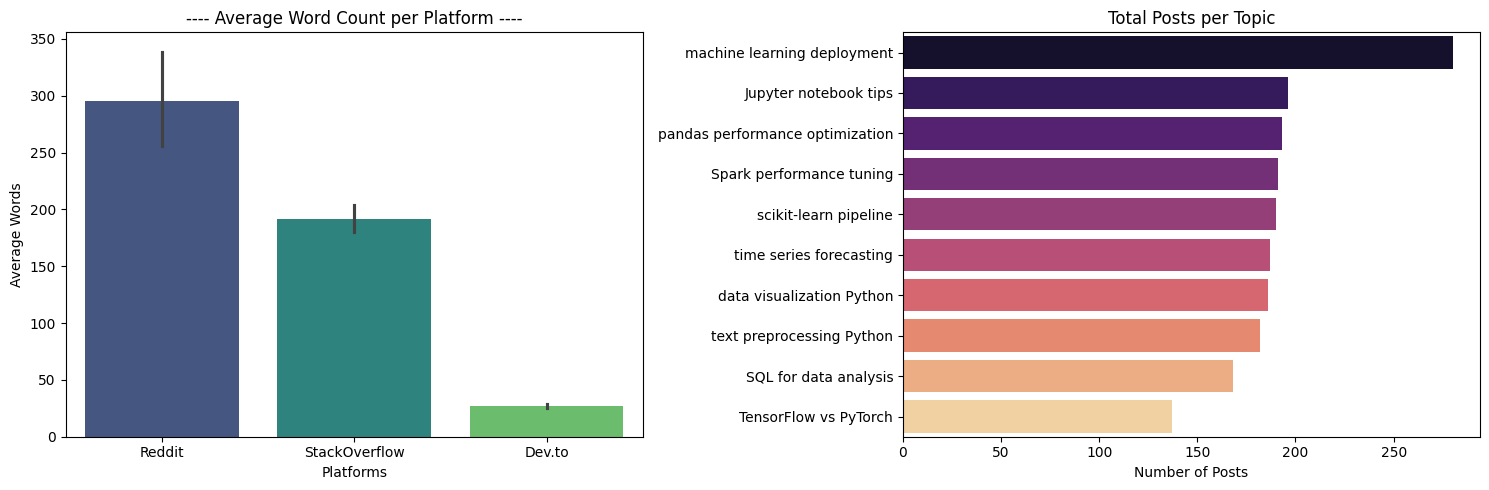

---- Average Word Count by Platform ----
platform
Reddit           295.59
StackOverflow    191.57
Dev.to            26.81
Name: word_count, dtype: float64


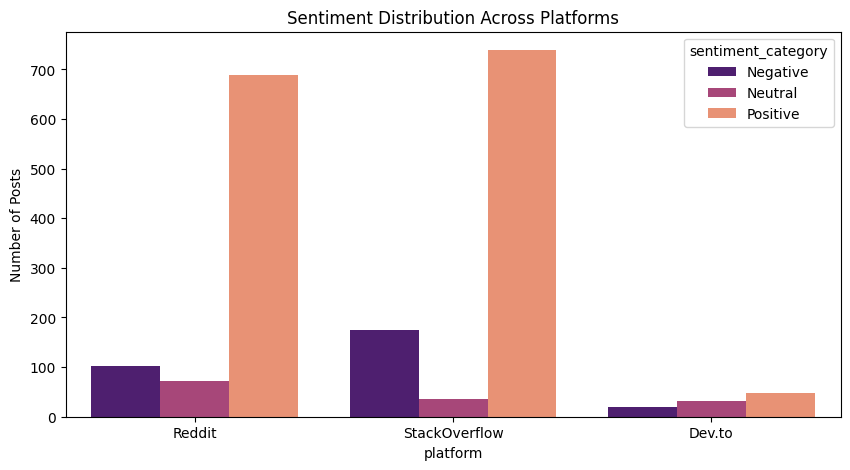

In [3]:
plt.figure(figsize=(15,5))

# Plot 1: Average Text Length per Platform
plt.subplot(1,2,1)
sns.barplot(
    data=df, 
    x="platform", 
    y="word_count", 
    estimator=lambda x: sum(x)/len(x),
    palette='viridis'
)
plt.title("---- Average Word Count per Platform ----")
plt.xlabel("Platforms")
plt.ylabel("Average Words")

# Plot 2: Topic Distribution
plt.subplot(1, 2, 2)
sns.countplot(
    data=df, 
    y='topic', 
    order=df['topic'].value_counts().index, 
    palette='magma'
)
plt.title('Total Posts per Topic')
plt.xlabel('Number of Posts')
plt.ylabel('')

plt.tight_layout()
plt.savefig("1.jpg")
plt.show()

print("---- Average Word Count by Platform ----")
print(df.groupby("platform")["word_count"].mean().round(2).sort_values(ascending=False))


# Sentiment by Platform
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='platform', hue='sentiment_category', palette='magma')
plt.title('Sentiment Distribution Across Platforms')
plt.ylabel('Number of Posts')
plt.savefig("2.jpg")
plt.show()

### Vocabulary Analysis

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


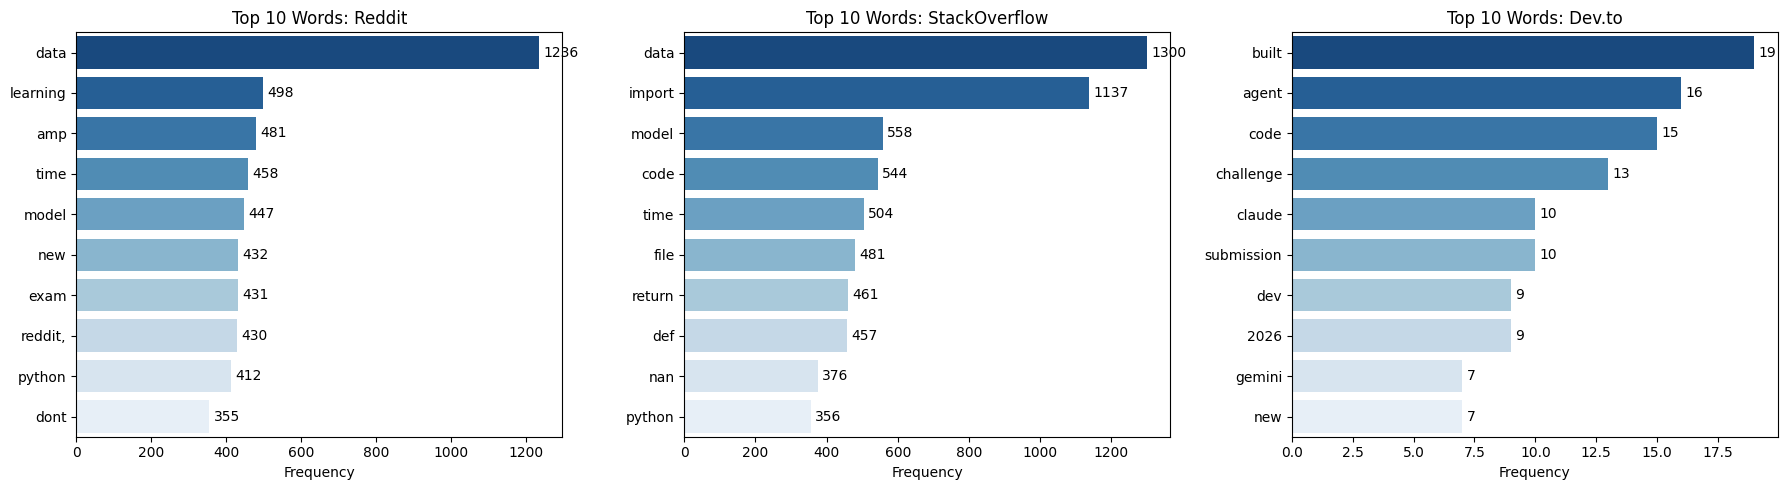

In [4]:
# download stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words("english"))
stop_words.update(["like","would","get","using","use","im","also","know","one","can"])

def get_top_words(text_series, n=10):
    all_words = "".join(text_series.astype(str)).split()
    # Filter out stopwords and short meaningless words
    clean_words = [word for word in all_words if word not in stop_words and len(word) > 2]

    return Counter(clean_words).most_common(n)

platforms = df["platform"].unique()

plt.figure(figsize=(18,5))
for i, platform in enumerate(platforms, 1):
    plt.subplot(1, len(platforms), i)

    platform_data = df[df["platform"] == platform]
    top_words = get_top_words(platform_data["text"], 10)
    
    words,counts = zip(*top_words)

    ax = sns.barplot(
        x=list(counts),
        y=list(words),
        hue=list(words), 
        palette='Blues_r'
    )
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', padding=3)
        
    plt.title(f'Top 10 Words: {platform}')
    plt.xlabel("Frequency")

plt.tight_layout()
plt.savefig("3.jpg")
plt.show()

### Engagement Pattern Analysis

C:\Users\User\AppData\Local\Temp\ipykernel_20132\957913225.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


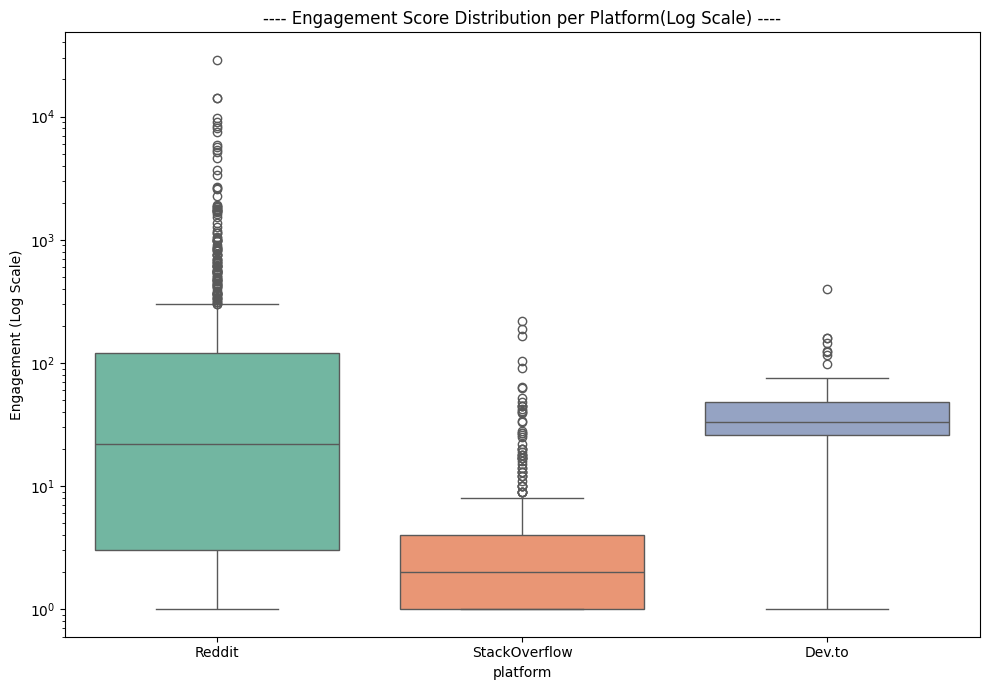

---- Top Engaging Post per Platform ----

REDDIT (Score: 28887):
Topic: data visualization Python
Title: oc i analyzed 15 years of comments on rrelationshipadvice

STACKOVERFLOW (Score: 220):
Topic: data visualization Python
Title: spark performance for scala vs python

DEV.TO (Score: 401):
Topic: machine learning deployment
Title: a new chapter dev is joining forces with major league hacking mlh


In [5]:
active_engagement = df[df["engagement"] > 0]

plt.figure(figsize=(10,7))
sns.boxplot(
    data=active_engagement, 
    x="platform", 
    y="engagement", 
    palette='Set2'
)
plt.yscale('log')
plt.title("---- Engagement Score Distribution per Platform(Log Scale) ----")
plt.ylabel("Engagement (Log Scale)")
plt.tight_layout()
plt.savefig("4.jpg")
plt.show()

print("---- Top Engaging Post per Platform ----")
for platform in platforms:
    top_post = df[df["platform"] == platform].nlargest(1, "engagement")
    print(f"\n{platform.upper()} (Score: {top_post['engagement'].values[0]}):")
    print(f"Topic: {top_post['topic'].values[0]}")
    print(f"Title: {top_post['title'].values[0]}")

# Knowledge Consistency & Fragmentation Analysis

### Topic Confusion Index (Cross-Platform Comparison)

---- Topic Confusion Index (Most Fragmented to Least) ----


,Topic,Avg_Similarity,Confusion_Index
5,machine learning deployment,0.2422,0.7578
7,scikit-learn pipeline,0.3093,0.6907
4,data visualization Python,0.3128,0.6872
2,Spark performance tuning,0.3130,0.6870
3,TensorFlow vs PyTorch,0.4096,0.5904
6,pandas performance optimization,0.4218,0.5782
9,time series forecasting,0.5138,0.4862
8,text preprocessing Python,0.5256,0.4744
0,Jupyter notebook tips,0.5375,0.4625
1,SQL for data analysis,0.5972,0.4028


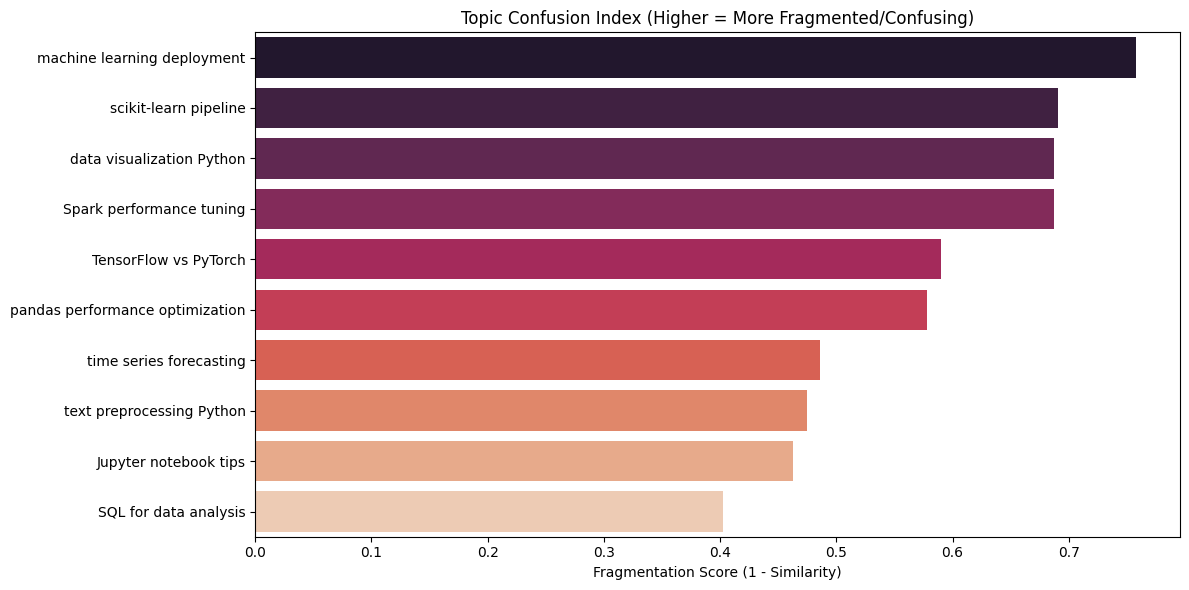

Saved Topic Metrics to: ../data/processed/dim_topic_metrics.csv


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# aggregate all text per topic per platform
agg_df = df.groupby(["topic","platform"])["text"] \
        .apply(lambda x: " ".join(x.astype(str))) \
        .reset_index()

topic_metrics = []
vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)

for topic in agg_df["topic"].unique():
    topic_data = agg_df[agg_df["topic"] == topic]
    platforms_present = topic_data["platform"].tolist()
    texts = topic_data["text"].tolist()

    if len(texts) > 1:
        # convert text to TF-IDF vectors
        tfidf_matrix = vectorizer.fit_transform(texts)

        # calculate cosine similarity matrix
        sim_matrix = cosine_similarity(tfidf_matrix)

        # extract the upper triangle of the matrix
        upper_tri = sim_matrix[np.triu_indices(sim_matrix.shape[0], k=1)]
        avg_similarity = np.mean(upper_tri)
    else:
        # If only one platform has data, it's perfectly consistent with itself
        avg_similarity = 1.0

    # Fragmentation = 1 - Similarity
    fragmentation = 1 - avg_similarity

    topic_metrics.append({
        "Topic" : topic,
        "Avg_Similarity" : avg_similarity,
        "Confusion_Index" : fragmentation 
    })

# convert to dataframe and sort by the most confusing topics
topic_confusion_df = pd.DataFrame(topic_metrics) \
                        .sort_values(by="Confusion_Index", ascending=False)

print("---- Topic Confusion Index (Most Fragmented to Least) ----")
display(topic_confusion_df.round(4))

# Visualization: Fragmentation per Topic
plt.figure(figsize=(12, 6))
sns.barplot(
    data=topic_confusion_df, 
    x='Confusion_Index', 
    y='Topic', 
    hue='Topic',
    palette='rocket'
)
plt.title('Topic Confusion Index (Higher = More Fragmented/Confusing)')
plt.xlabel('Fragmentation Score (1 - Similarity)')
plt.ylabel('')
plt.tight_layout()
plt.savefig("5.jpg")
plt.show()


# Save the Topic metrics as a dimension table
topic_confusion_df.to_csv('../data/processed/dim_topic_metrics.csv', index=False)
print("Saved Topic Metrics to: ../data/processed/dim_topic_metrics.csv")

### Platform Consistency & Reliability Scores

---- Platform Reliability Scores ----


,Platform,Consistency_Score,Internal_Fragmentation,Reliability_Score
0,Reddit,0.0301,0.9699,1.0310
1,StackOverflow,0.0265,0.9735,1.0272
2,Dev.to,0.0142,0.9858,1.0144


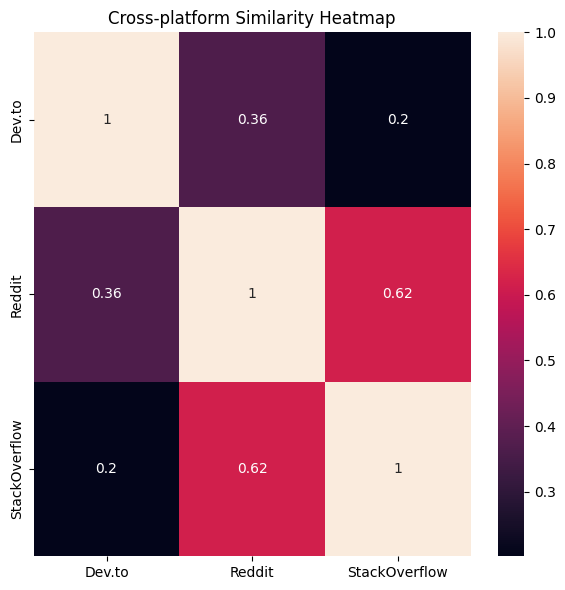

Saved Platform Metrics to: ../data/processed/dim_platform_metrics.csv


In [7]:
platform_metrics = []

for platform in platforms:
    # get all post from this platform
    plat_texts = df[df["platform"] == platform]["text"].tolist()

    if len(plat_texts) >1:
        tfidf_matrix = vectorizer.fit_transform(plat_texts)
        sim_matrix = cosine_similarity(tfidf_matrix)

        # Internal Consistency : how similar are posts within the same platform?
        upper_tri = sim_matrix[np.triu_indices(sim_matrix.shape[0], k=1)]
        consistency_score = np.mean(upper_tri)
    else:
        consistency_score = 0

    # Reliability Score: inverse of its internal fragmentation (1 / (1 - consistency))
    fragmentation = 1 - consistency_score
    reliability_score = 1/ (fragmentation + 1e-5) # to prevent division by zero

    platform_metrics.append({
        "Platform": platform,
        "Consistency_Score": consistency_score,
        "Internal_Fragmentation": fragmentation,
        "Reliability_Score": reliability_score
    })

platform_eval_df = pd.DataFrame(platform_metrics).sort_values(by="Reliability_Score", ascending=False)

print("---- Platform Reliability Scores ----")
display(platform_eval_df.round(4))


# visualization : Cross-Platform Similarity Heatmap
# use the aggregated texts across all topics to see how platform relate overall
all_agg_texts = df.groupby("platform")["text"].apply(lambda x: " ".join(x.astype(str))).reset_index()
all_tfidf = vectorizer.fit_transform(all_agg_texts["text"])
cross_plat_sim = cosine_similarity(all_tfidf)

plt.figure(figsize=(6,6))
sns.heatmap(
    cross_plat_sim,
    xticklabels=all_agg_texts["platform"],
    yticklabels=all_agg_texts["platform"],
    annot=True,
    
)
plt.title("Cross-platform Similarity Heatmap")
plt.tight_layout()
plt.savefig("6.jpg")
plt.show()



# Save the Platform metrics as a dimension table
platform_eval_df.to_csv('../data/processed/dim_platform_metrics.csv', index=False)
print("Saved Platform Metrics to: ../data/processed/dim_platform_metrics.csv")

# Clustering & Knowledge Pattern Analysis

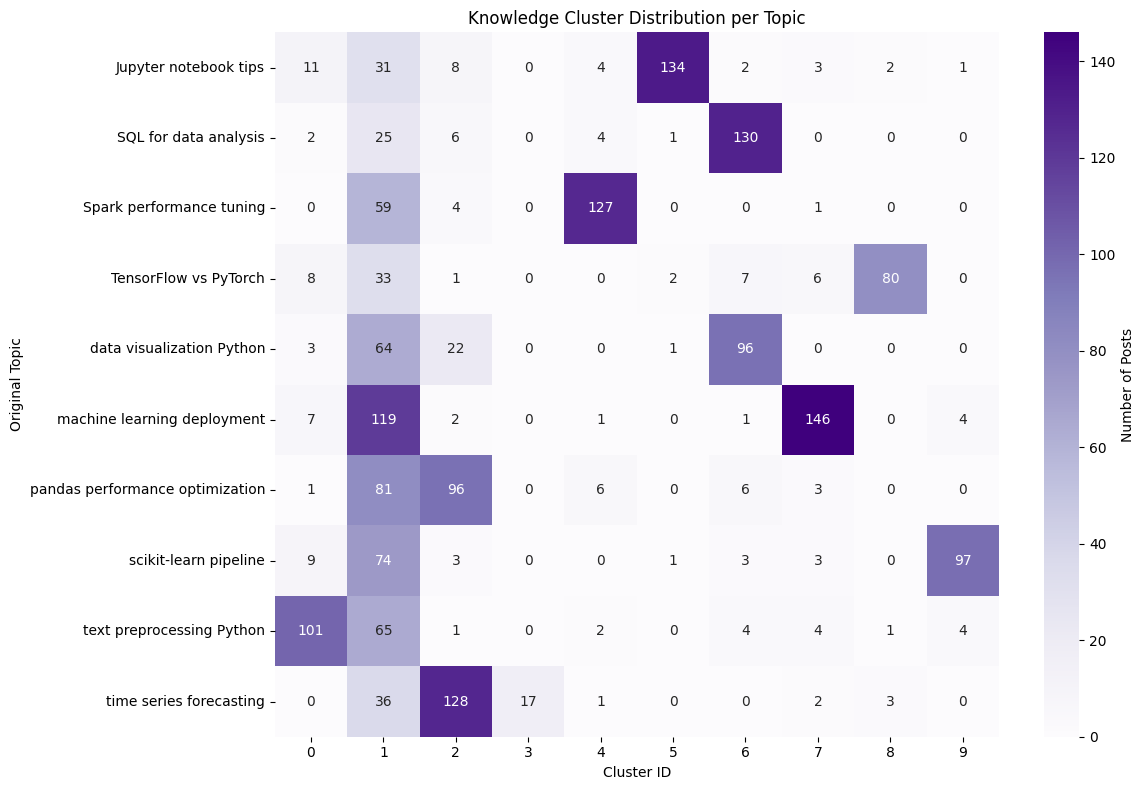

----- Cluster Interpretation ----
machine learning deployment ::::::::: Moderately Fragmented (Dominant Cluster holds 52.1%)
pandas performance optimization ::::::::: Moderately Fragmented (Dominant Cluster holds 49.7%)
TensorFlow vs PyTorch ::::::::: Moderately Fragmented (Dominant Cluster holds 58.4%)
data visualization Python ::::::::: Moderately Fragmented (Dominant Cluster holds 51.6%)
SQL for data analysis ::::::::: Highly Consistent (Dominating Cluster holds 77.4%)
Jupyter notebook tips ::::::::: Highly Consistent (Dominating Cluster holds 68.4%)
scikit-learn pipeline ::::::::: Moderately Fragmented (Dominant Cluster holds 51.1%)
time series forecasting ::::::::: Highly Consistent (Dominating Cluster holds 68.4%)
text preprocessing Python ::::::::: Moderately Fragmented (Dominant Cluster holds 55.5%)
Spark performance tuning ::::::::: Highly Consistent (Dominating Cluster holds 66.5%)


In [8]:
from sklearn.cluster import KMeans

# Re-vectorize the individual posts (ignoring platform/topic labels)
vectorizer_full = TfidfVectorizer(stop_words="english", max_features=5000)
x = vectorizer_full.fit_transform(df["text"].dropna())

# 10 topics ==== 10 clusters
kmeans =KMeans(n_clusters=10, random_state=42,n_init=10)
df["Cluster_ID"] = kmeans.fit_predict(x)

# Create a cross-tabulation to see how topics spread across clusters
cluster_distribution = pd.crosstab(df["topic"],df["Cluster_ID"])

# visualization : heatmap of Cluster Distribution
plt.figure(figsize=(12,8))
sns.heatmap(
    cluster_distribution,
    cmap="Purples",
    annot=True,
    fmt="d",
    cbar_kws={"label": "Number of Posts"}
)
plt.title("Knowledge Cluster Distribution per Topic")
plt.xlabel("Cluster ID")
plt.ylabel("Original Topic")
plt.tight_layout()
plt.savefig("7.jpg")
plt.show()


# Interpretation logic
print("----- Cluster Interpretation ----")
for topic in df["topic"].unique():
    topic_clusters = cluster_distribution.loc[topic]

    dominant_cluster_pct = (topic_clusters.max() / topic_clusters.sum()) * 100

    if dominant_cluster_pct > 60:
        print(f"{topic} ::::::::: Highly Consistent (Dominating Cluster holds {dominant_cluster_pct:.1f}%)")
    elif dominant_cluster_pct > 40:
        print(f"{topic} ::::::::: Moderately Fragmented (Dominant Cluster holds {dominant_cluster_pct:.1f}%)")
    else:
        print(f"{topic} ::::::::: Highly Fragmented (Spread across many clusters, Max is {dominant_cluster_pct:.1f}%)")  

In [9]:
# Export the main dataframe
export_path = '../data/processed/fact_posts.csv'
df.to_csv(export_path, index=False)

print("="*60)
print("MODELING & ANALYSIS COMPLETE")
print(f"Final BI-ready Fact Table saved to: {export_path}")
print("="*60)

MODELING & ANALYSIS COMPLETE
Final BI-ready Fact Table saved to: ../data/processed/fact_posts.csv
